# Capa 3 — Oferta de actividades para jóvenes en Lima Este

Qué actividades, talleres, eventos, programas, servicios y espacios para jóvenes se ofrecieron en los siete
distritos entre enero de 2024 y septiembre de 2026, y qué evidencia hay de que alguien participó en ellos o los
buscó. Para reproducirlo:

```bash
python scripts/capa3_noticias_gobpe.py listar && python scripts/capa3_noticias_gobpe.py detalle
python scripts/capa3_noticias_gobpe.py sectores && python scripts/capa3_noticias_gobpe.py detalle_sectores
python scripts/capa3_noticias_wp.py
python scripts/capa3_triaje.py
python scripts/capa3_validar_registro.py   # después de codificar el registro a mano
```

### Cómo leer esta capa

| Tipo de evidencia | Qué permite afirmar |
|---|---|
| **Oferta** | La actividad se ofreció o se realizó. **No prueba que interese a los jóvenes.** |
| **Participación declarada** | Quien organiza informa inscritos, asistentes o participantes. Cifras aproximadas, no auditadas. |
| **Demanda observada** | Hubo más interesados que cupos (inscripciones agotadas, inscritos por encima del cupo). |

- **El registro no es un censo de la oferta.** Solo contiene lo que se publicó en internet, y las
  municipalidades publican con frecuencia muy distinta. Los conteos por distrito o por tema describen **lo que se
  pudo observar**, no la oferta real ni su volumen.
- **A quién se dirige** (`incluye_15_29`): `juventud` (dirigida a jóvenes o con edades dentro de 15–29),
  `adolescentes` (mezcla niños con adolescentes o "jóvenes"; en la práctica, casi siempre hasta 17 años),
  `todo público` y `no` (fuera del rango).
- Metodología, reglas de inclusión y fuentes: `fuentes/metodologia_capa3.md`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 220); pd.set_option("display.max_rows", 200)
RAIZ = Path("..")
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRIS_SERIE, TINTA, TINTA_2, GRILLA, EJE, FONDO = "#b5b3ab", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "axes.edgecolor": EJE, "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 110,
})
DISTRITOS = ["Ate", "Chaclacayo", "El Agustino", "La Molina", "Lurigancho-Chosica", "San Juan de Lurigancho", "Santa Anita"]
CORTO = {"San Juan de Lurigancho": "SJL", "Lurigancho-Chosica": "Lurigancho-\nChosica"}
EVIDENCIA = ["oferta", "participación declarada", "demanda observada"]
EDAD = ["juventud", "adolescentes", "todo público", "no indica", "no"]

reg = pd.read_csv(RAIZ / "fuentes" / "capa3_registro_oferta.csv", dtype={"ubigeo": str})
# Una actividad puede tener varios distritos y temas: se expanden para contar presencia, no para sumar cifras.
por_distrito = reg.assign(distrito=reg.distrito.str.split("; ")).explode("distrito").reset_index(drop=True)
por_tema = por_distrito.assign(tematica=por_distrito.tematica.str.split("; ")).explode("tematica").reset_index(drop=True)
print(f"{len(reg)} actividades registradas ({reg.distrito.str.contains(';').sum()} en más de un distrito); "
      f"{len(por_distrito)} filas actividad × distrito")
display(reg.evidencia.value_counts().to_frame("actividades"))

150 actividades registradas (16 en más de un distrito); 175 filas actividad × distrito


,actividades
evidencia,
oferta,88
participación declarada,58
demanda observada,4


## 1. Cobertura de las fuentes

Cuántas notas publicó cada municipalidad en gob.pe que coinciden con la búsqueda (enero de 2024 a septiembre de
2026), por año, y cuántas actividades se registraron. Mide el **sesgo de visibilidad**.

In [2]:
listado = pd.read_csv(RAIZ / "data" / "raw" / "capa3" / "gobpe_listado.csv", dtype={"ubigeo": str})
cand = pd.read_csv(RAIZ / "data" / "processed" / "capa3_notas_candidatas.csv", dtype={"ubigeo": str})
notas_anio = pd.crosstab(listado.distrito, listado.fecha.str[:4]).reindex(DISTRITOS).fillna(0).astype(int)
notas_anio.columns = [f"notas {c}" for c in notas_anio.columns]
cobertura = notas_anio.assign(**{
    "candidatas": cand[cand.sitio.isin(["gob.pe", "munichosica"])].groupby("distrito").size().reindex(DISTRITOS).fillna(0).astype(int),
    "actividades registradas": por_distrito.groupby("distrito").size().reindex(DISTRITOS).fillna(0).astype(int),
    "de la municipalidad": por_distrito[por_distrito.tipo_organizador.isin(["municipalidad distrital", "alianza público-privada"])]
        .groupby("distrito").size().reindex(DISTRITOS).fillna(0).astype(int),
})
display(cobertura)
print("Fuentes de las actividades registradas:")
display(reg.fuente_tipo.value_counts().to_frame("actividades"))

,notas 2024,notas 2025,notas 2026,candidatas,actividades registradas,de la municipalidad
distrito,,,,,,
Ate,68,57,25,49,26,10
Chaclacayo,5,1,0,1,3,1
El Agustino,134,218,56,102,29,22
La Molina,30,112,59,85,24,19
Lurigancho-Chosica,15,28,29,25,18,12
San Juan de Lurigancho,1,128,96,39,42,16
Santa Anita,153,44,45,59,33,25


Fuentes de las actividades registradas:


,actividades
fuente_tipo,
nota de prensa municipal (gob.pe),96
nota institucional (gob.pe),25
sitio web municipal,11
nota institucional (SERPAR),8
nota institucional (SENAJU),7
prensa,2
nota institucional (SERPAR); prensa,1


### 1.1 Lectura

- **La visibilidad es muy desigual.** Chaclacayo publicó 6 notas en gob.pe en casi tres años (ninguna en 2026) y
  sus pocas actividades registradas vienen sobre todo de entidades nacionales. **San Juan de Lurigancho** casi no
  publicó en gob.pe en 2024 (su sitio anterior ya no está disponible) y **La Molina** publicó poco ese año. Las
  diferencias entre distritos no deben leerse como diferencias de oferta.
- **El Agustino** publica muchas notas, pero breves (una o dos líneas, estilo red social), con poca información
  sobre edades, costos y participantes.
- Casi toda la evidencia viene de **quien organiza la actividad** (municipalidades y entidades públicas). La oferta de
  organizaciones sociales, parroquias, ONG y academias privadas casi no aparece.

## 2. Tipo de evidencia por distrito

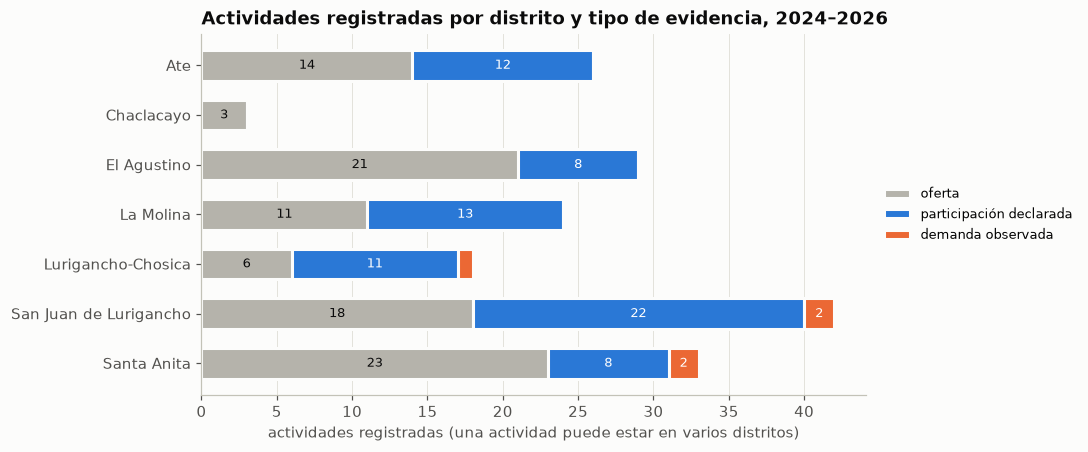

evidencia,oferta,participación declarada,demanda observada,total
distrito,,,,
Ate,14,12,0,26
Chaclacayo,3,0,0,3
El Agustino,21,8,0,29
La Molina,11,13,0,24
Lurigancho-Chosica,6,11,1,18
San Juan de Lurigancho,18,22,2,42
Santa Anita,23,8,2,33


In [3]:
ev = por_distrito.pivot_table(index="distrito", columns="evidencia", values="id", aggfunc="count").reindex(
    index=DISTRITOS, columns=EVIDENCIA).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 4.2))
izq = np.zeros(len(ev))
for col, color in zip(EVIDENCIA, [GRIS_SERIE, AZUL, NARANJA]):
    ax.barh(ev.index, ev[col], left=izq, color=color, edgecolor=FONDO, linewidth=2, height=0.62, label=col)
    for y, (x0, w) in enumerate(zip(izq, ev[col])):
        if w >= 2:
            ax.text(x0 + w / 2, y, int(w), ha="center", va="center", fontsize=8.5, color=TINTA if color == GRIS_SERIE else "white")
    izq += ev[col].values
ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlabel("actividades registradas (una actividad puede estar en varios distritos)")
ax.set_title("Actividades registradas por distrito y tipo de evidencia, 2024–2026")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5)
plt.tight_layout(); plt.show()
display(ev.assign(total=ev.sum(axis=1)))

## 3. ¿A quién se dirige la oferta?

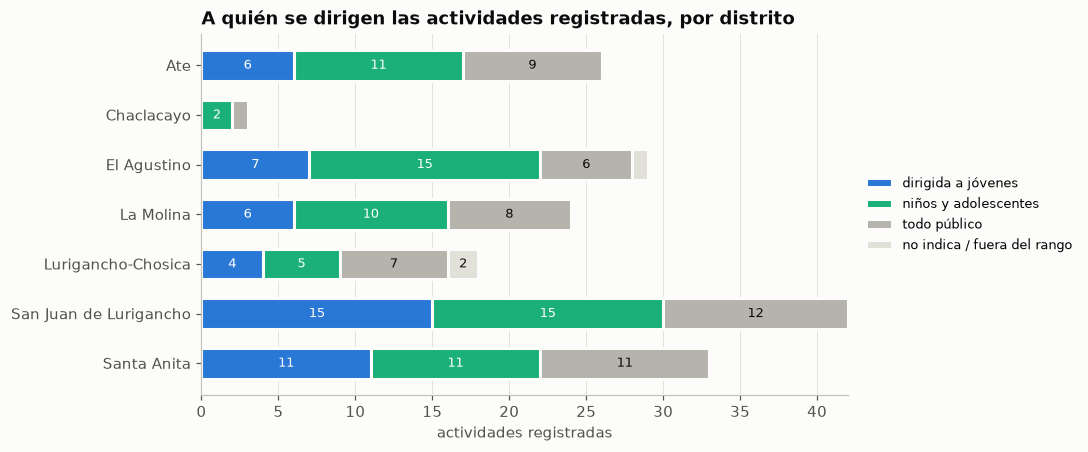

incluye_15_29,juventud,adolescentes,todo público,no indica,no,total
distrito,,,,,,
Ate,6,11,9,0,0,26
Chaclacayo,0,2,1,0,0,3
El Agustino,7,15,6,1,0,29
La Molina,6,10,8,0,0,24
Lurigancho-Chosica,4,5,7,1,1,18
San Juan de Lurigancho,15,15,12,0,0,42
Santa Anita,11,11,11,0,0,33


Costo según a quién se dirige (actividades):


costo,gratuito,mixto,no indica,pagado,total
incluye_15_29,,,,,
juventud,31,1,9,2,43
adolescentes,39,2,6,6,53
todo público,26,0,24,1,51
no indica,1,0,1,0,2
no,1,0,0,0,1
total,98,3,40,9,150


Tipo de oferta según a quién se dirige:


incluye_15_29,juventud,adolescentes,todo público,no indica,no,total
tipo_oferta,,,,,,
beca o premio,3,1,0,0,0,4
concurso o competencia,2,8,7,0,0,17
convocatoria de voluntariado,5,0,0,1,0,6
espacio o infraestructura,2,1,10,0,0,13
evento,8,6,11,0,0,25
feria,3,2,9,0,0,14
programa,11,6,2,0,0,19
servicio,2,6,4,0,0,12
taller o curso,7,23,8,1,1,40


Organizador:


ambito,distrital,metropolitano,nacional,total
tipo_organizador,,,,
Municipalidad de Lima / SERPAR,1,11,0,12
alianza público-privada,21,0,0,21
gobierno nacional,18,10,2,30
municipalidad distrital,83,1,0,84
privado,1,0,0,1
sociedad civil,2,0,0,2
total,126,22,2,150


Modalidad: {'presencial': 142, 'virtual': 5, 'mixta': 2, 'no indica': 1}


In [4]:
edad = por_distrito.pivot_table(index="distrito", columns="incluye_15_29", values="id", aggfunc="count").reindex(
    index=DISTRITOS, columns=EDAD).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 4.2))
izq = np.zeros(len(edad)); colores = [AZUL, AQUA, GRIS_SERIE, GRILLA, GRILLA]
etiquetas = ["dirigida a jóvenes", "niños y adolescentes", "todo público", "no indica / fuera del rango", None]
otros = edad[["no indica", "no"]].sum(axis=1)
for col, color, etq in zip(["juventud", "adolescentes", "todo público", "otros"], colores, etiquetas):
    vals = otros if col == "otros" else edad[col]
    ax.barh(edad.index, vals, left=izq, color=color, edgecolor=FONDO, linewidth=2, height=0.62, label=etq)
    for y, (x0, w) in enumerate(zip(izq, vals)):
        if w >= 2:
            ax.text(x0 + w / 2, y, int(w), ha="center", va="center", fontsize=8.5, color="white" if color in (AZUL, AQUA) else TINTA)
    izq += vals.values
ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlabel("actividades registradas")
ax.set_title("A quién se dirigen las actividades registradas, por distrito")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5)
plt.tight_layout(); plt.show()
display(edad.assign(total=edad.sum(axis=1)))
print("Costo según a quién se dirige (actividades):")
display(pd.crosstab(reg.incluye_15_29, reg.costo, margins=True, margins_name="total").reindex(EDAD + ["total"]).dropna(how="all").fillna(0).astype(int))
print("Tipo de oferta según a quién se dirige:")
display(pd.crosstab(reg.tipo_oferta, reg.incluye_15_29, margins=True, margins_name="total").reindex(columns=EDAD + ["total"]).fillna(0).astype(int))
print("Organizador:")
display(pd.crosstab(reg.tipo_organizador, reg.ambito, margins=True, margins_name="total"))
print("Modalidad:", reg.modalidad.value_counts().to_dict())

### 3.1 Lectura

- **Menos de un tercio de la oferta registrada está dirigida a jóvenes** (`juventud`). La mayor parte es para
  niños y adolescentes, casi siempre de 6 a 17 años (talleres de verano, escuelas deportivas, Academia IPD), o
  abierta a todo público. **Para jóvenes de 18 a 29 años la oferta publicada es escasa** y se concentra en
  preparación preuniversitaria, empleo y voluntariado.
- **La mayoría es gratuita.** Lo pagado son sobre todo talleres de verano y escuelas deportivas para niños y
  adolescentes (S/ 50 por ciclo en Ate; S/ 60–70 al mes en SERPAR, El Agustino y Santa Anita; S/ 140 por taller en
  Santa Anita en 2025) y las academias preuniversitarias municipales (S/ 150 al mes en Santa Anita).
- **Casi todo es presencial** (142 de 150). Lo virtual son cursos de empleabilidad, clases de inglés y
  postulaciones en línea; la hackathon de SJL y los talleres de SENAJU fueron mixtos.
- **Las municipalidades distritales organizan la mayor parte**; el IPD, el MTPE, el Ministerio de Cultura, DEVIDA,
  SENAJU y la Municipalidad de Lima (SERPAR) aportan oferta propia en varios distritos, sobre todo en SJL.

## 4. Temas

Número de actividades por tema y distrito (una actividad puede tener más de un tema). Una celda vacía significa
que **no se encontró** una actividad publicada, no que no exista.

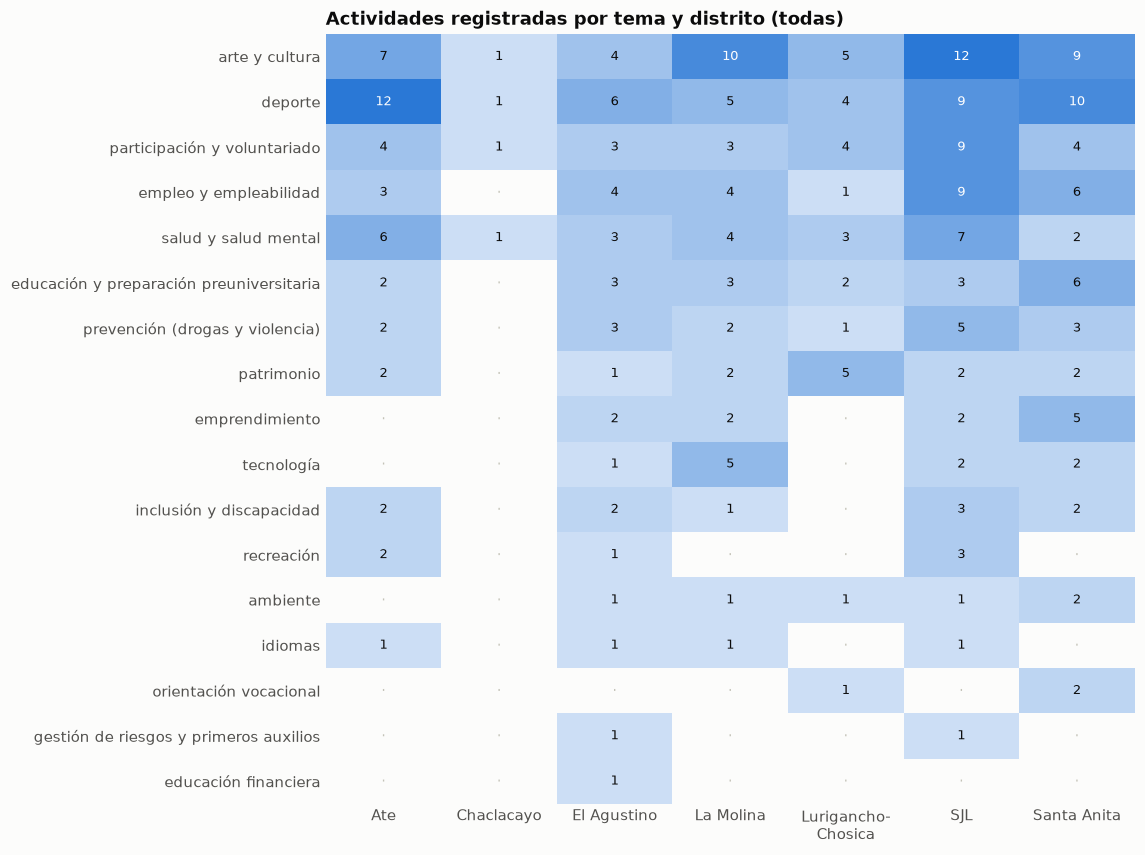

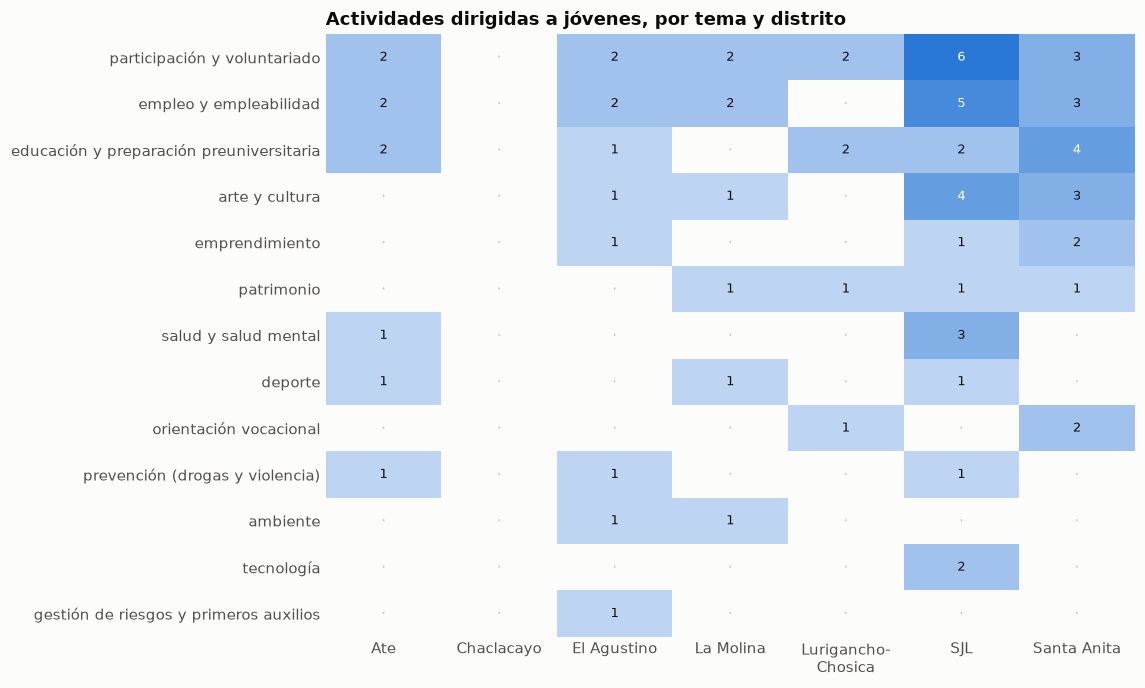

In [5]:
def matriz(df, titulo):
    tabla = df.pivot_table(index="tematica", columns="distrito", values="id", aggfunc="nunique").reindex(
        columns=DISTRITOS).fillna(0).astype(int)
    tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(10.5, 0.38 * len(tabla) + 1.4))
    v = tabla.values
    ax.imshow(np.where(v > 0, v, np.nan), cmap=LinearSegmentedColormap.from_list("azul", ["#dbe8f8", AZUL]), aspect="auto", vmin=0)
    for (i, j), n in np.ndenumerate(v):
        ax.text(j, i, n if n else "·", ha="center", va="center", fontsize=8.5,
                color="white" if n >= max(v.max() * 0.6, 1) else (TINTA if n else EJE))
    ax.set_xticks(range(len(DISTRITOS)), [CORTO.get(d, d) for d in DISTRITOS])
    ax.set_yticks(range(len(tabla)), tabla.index); ax.grid(False); ax.tick_params(length=0)
    [s.set_visible(False) for s in ax.spines.values()]
    ax.set_title(titulo)
    plt.tight_layout(); plt.show()
    return tabla

t_todas = matriz(por_tema, "Actividades registradas por tema y distrito (todas)")
t_jov = matriz(por_tema[por_tema.incluye_15_29 == "juventud"], "Actividades dirigidas a jóvenes, por tema y distrito")

### 4.1 Lectura

- **Arte y cultura (48 actividades) y deporte (47)** son los temas con más actividades, pero en su mayoría son
  para niños y adolescentes o para todo público. **Solo 3 actividades de deporte se dirigen a jóvenes.**
- **Lo dirigido a jóvenes** (43 actividades) se concentra en **participación y voluntariado** (17: FestiJoven,
  Minka Joven, CADE Universitario, promotores ambientales, Defensores del Patrimonio), **empleo y empleabilidad**
  (14: Mi Primera Chamba, Actívate Joven, Jóvenes Productivos, pasantías) y **preparación preuniversitaria**
  (11: academias municipales en Lurigancho-Chosica, Ate y Santa Anita; becas en El Agustino, SJL y Santa Anita).
- **Poca oferta dirigida a jóvenes en:** salud y salud mental (4, entre ellas una campaña de salud juvenil en SJL),
  emprendimiento (4), deporte (3) y tecnología (2: una hackathon y un taller de Canva, ambos en SJL). Para niños y
  adolescentes o todo público hay algo más: computación gratuita en La Molina (10–18 años), charlas de prevención
  de DEVIDA en colegios de seis distritos, cursos de quechua en SJL.

## 5. Participación declarada y demanda observada

Todas las cifras son declaradas por quien organiza. Se muestran con su texto original y la población a la que se
refieren. **No se suman ni se comparan entre distritos**: miden cosas distintas (inscritos, asistentes,
egresados, becarios) con distinto rigor, y algunas cubren a toda Lima.

In [6]:
cols = ["id", "distrito", "anio", "nombre", "incluye_15_29", "costo", "cifra_tipo", "cifra_texto", "cifra_poblacion"]
print("Demanda observada:")
display(reg[reg.evidencia == "demanda observada"][cols + ["senal_demanda"]])
print("Participación declarada en actividades dirigidas a jóvenes:")
display(reg[(reg.evidencia == "participación declarada") & (reg.incluye_15_29 == "juventud")][cols].sort_values(["distrito", "anio"]))
print("Participación declarada en actividades para niños y adolescentes o todo público:")
display(reg[(reg.evidencia == "participación declarada") & (reg.incluye_15_29 != "juventud")][cols].sort_values(["distrito", "anio"]))

Demanda observada:


,id,distrito,anio,nombre,incluye_15_29,costo,cifra_tipo,cifra_texto,cifra_poblacion,senal_demanda
77,C3-078,Lurigancho-Chosica,2026,Taller de verano arqueológico 'Aventureros de Cajamarquilla',no,gratuito,inscritos,previsto para 25 niños; se inscribieron más de 60,niños de 7 a 11 años,inscritos (más de 60) superan el cupo previsto (25)
83,C3-084,San Juan de Lurigancho,2024,"Talleres juveniles: arte, desarrollo y empleabilidad (verano 2024), sede presencial en...",juventud,gratuito,inscritos (todas las sedes),"'se agotaron las inscripciones, más de cinco mil inscritos' en los diez talleres; se e...",jóvenes de 15 a 29 años de todo el país,inscripciones agotadas; inscritos (más de 5 mil) muy por encima de la meta (casi mil)
120,C3-121,San Juan de Lurigancho; Santa Anita,2026,"Academia IPD (talleres deportivos gratuitos): sedes Canto Grande, Chacarilla de Otero ...",adolescentes,gratuito,inscritos,2026 (Lima Metropolitana): 'ya se agotaron los 19 mil cupos'; 'ante el gran éxito ... ...,"niñas, niños y adolescentes de 6 a 17 años de Lima Metropolitana",cupos agotados (19 mil) y ampliación de 9 500 vacantes por la demanda (enero de 2026);...
122,C3-123,Santa Anita,2024,Academia Preuniversitaria Municipal CEPREMUNI y concursos de becas,juventud,mixto,postulantes a becas,"'se entregaron 10 becas a los ganadores, donde compitieron más de 80 jóvenes' (abril d...",jóvenes que postulan a la universidad,más de 80 postulantes para 10 becas (abril de 2024)


Participación declarada en actividades dirigidas a jóvenes:


,id,distrito,anio,nombre,incluye_15_29,costo,cifra_tipo,cifra_texto,cifra_poblacion
2,C3-003,Ate,2024,Programa municipal 'Mi Primera Chamba',juventud,no indica,jóvenes con empleo (resultado declarado),'a través del Programa Municipal Mi Primera Chamba 143 jóvenes ateños cuentan con nuev...,jóvenes
5,C3-006,Ate,2024,Academia Preuniversitaria Municipal CEPREMUNI (Ate),juventud,pagado,ingresantes (resultado declarado),"35 alumnos del Ciclo Invierno 2024 ingresaron a San Marcos, Villarreal, La Agraria, La...",estudiantes preuniversitarios
10,C3-011,Ate,2025,'Minka Joven': voluntariado para recuperar espacios públicos (primera intervención en ...,juventud,gratuito,voluntarios,con la presencia de más de 20 jóvenes,jóvenes de 15 a 29 años
19,C3-020,Ate; San Juan de Lurigancho,2025,Primer Programa de Pasantías del IMP con propuestas urbanas para Lima Este,juventud,gratuito,pasantes,'22 estudiantes de diversas especialidades',estudiantes (distrito de residencia no indicado)
34,C3-035,El Agustino,2024,"Concurso 'Demuestra tu talento' (canto y baile, Día de la Primavera)",juventud,gratuito,participantes (sin número),'adolescentes y jóvenes del distrito participaron' (sin número),adolescentes y jóvenes
42,C3-043,El Agustino,2025,"Curso 'Mini Comando' (primeros auxilios, rescate y supervivencia)",juventud,no indica,egresados (sin número),clausura con participantes felicitados (sin número),jóvenes
45,C3-046,El Agustino,2025,Muni Becas: becas de preparación preuniversitaria,juventud,gratuito,becarios,'hemos lanzado 100 becas' (agosto de 2025); '100 jóvenes transforman su futuro con Mun...,jóvenes que terminan o terminaron la secundaria
52,C3-053,La Molina,2025,Taller de tiro con arco,juventud,no indica,alumnos por horario,'aproximadamente 30 alumnos por horario'; 'notable aumento en la participación',jóvenes (edad no indicada)
60,C3-061,La Molina,2025,I Encuentro de Jóvenes para la Formalización Laboral (UNALM),juventud,gratuito,asistentes (sin número exacto),'decenas de alumnos',universitarios
69,C3-070,Lurigancho-Chosica,2024,Academia Preuniversitaria Municipal CEPREMUNI,juventud,gratuito,estudiantes matriculados,"más de 180 estudiantes de la Academia Preuniversitaria Municipal (feria vocacional, 16...",estudiantes preuniversitarios


Participación declarada en actividades para niños y adolescentes o todo público:


,id,distrito,anio,nombre,incluye_15_29,costo,cifra_tipo,cifra_texto,cifra_poblacion
0,C3-001,Ate,2024,Talleres y terapias gratuitas de la OMAPED para personas con discapacidad,todo público,gratuito,usuarios,aniversario 'junto a los más de 300 usuarios' (mayo de 2024),personas con discapacidad de todas las edades
6,C3-007,Ate,2024,"Concurso de Bandas Escolares de Música (2.ª edición, 2024)",adolescentes,gratuito,instituciones participantes,5 instituciones educativas emblemáticas del distrito y 3 invitadas,colegios
14,C3-015,Ate,2026,"Vacaciones Útiles (ediciones 2024, 2025 y 2026)",adolescentes,pagado,participantes (sin número),"'cientos de niños, adolescentes y jóvenes ... participan de los diferentes talleres' (...","niños, adolescentes y jóvenes de 6 a 17 años"
16,C3-017,Ate; El Agustino; La Molina; Lurigancho-Chosica; San Juan de Lurigancho; Santa Anita,2026,"'Habla Franco': charlas y ferias de prevención del consumo de drogas en colegios, univ...",adolescentes,gratuito,estudiantes alcanzados,SJL: 450 estudiantes (I.E. Gran Amauta Mariátegui) y cerca de 120 (I.E. Santa María); ...,estudiantes de secundaria
17,C3-018,Ate; La Molina,2026,Concurso Escolar 'Encuentro de Curacas',adolescentes,gratuito,participantes,'más de 400 estudiantes' (2026),escolares
18,C3-019,Ate; Lurigancho-Chosica; San Juan de Lurigancho,2025,"'Gana Cultura, juegos con identidad' en sitios arqueológicos",adolescentes,gratuito,participantes (todas las sedes),1269 participantes en quince presentaciones (incluye sedes fuera de Lima Este),todas las edades
33,C3-034,El Agustino,2024,Campeonato Relámpago de Vóley de Inclusión,todo público,no indica,equipos,un total de 14 equipos compitieron,equipos (edades no indicadas)
36,C3-037,El Agustino,2024,Taller de autoestima para adolescentes,adolescentes,no indica,participantes (sin número),'los adolescentes participaron en dinámicas grupales' (sin número),adolescentes
44,C3-045,El Agustino,2025,"Talleres municipales de danza, marinera, box y básquet",adolescentes,mixto,participantes (sin número),clausura del taller de verano de básquet con 'los más pequeños como los jóvenes' (sin ...,niños y jóvenes
48,C3-049,El Agustino; La Molina; Ate,2025,Programa 'Vida Saludable' del IPD (juegos y actividad física con municipalidades),adolescentes,gratuito,beneficiarios,La Molina: 'más de 500 beneficiarios' (enero de 2026),"niños, niñas y familias"


### 5.1 Lectura

- **La demanda casi nunca se puede observar.** Solo 4 de 150 actividades tienen una señal de demanda, porque las
  notas rara vez informan a la vez los cupos y los interesados:
  - **Becas de CEPREMUNI (Santa Anita, 2024):** más de 80 jóvenes compitieron por 10 becas. Es la única señal
    local sobre jóvenes; se refiere a las becas gratuitas, no a la academia pagada, que ese mismo mes tenía
    vacantes en la tarde.
  - **Talleres juveniles de SENAJU (verano 2024):** se agotaron las inscripciones (más de 5 mil para una meta de
    casi mil), pero la cifra agrega cinco sedes de Lima (una en SJL) y talleres virtuales nacionales.
  - **Academia IPD (enero de 2026):** se agotaron los 19 mil cupos gratuitos de Lima Metropolitana y se abrieron
    9 500 más, dos sedes de ampliación en SJL; SJL fue el distrito con más inscritos. Es para 6 a 17 años.
  - **Taller arqueológico en Cajamarquilla (2026):** 60 inscritos para 25 cupos, pero para niños de 7 a 11 años.
- **Participación declarada:** las cifras más altas corresponden a actividades para niños y adolescentes o para
  todo público (6 304 participantes en los talleres deportivos de La Molina en 2024; más de 5 000 inscritos en el
  verano 2025 de Santa Anita; más de 1 500 en el verano 2026 de Lurigancho-Chosica). En la oferta dirigida a
  jóvenes, las cifras son menores: por ejemplo, 400 inscritos en la hackathon de SJL, 300 asistentes a la feria
  vocacional de Chosica, 180 alumnos en su academia preuniversitaria, 143 jóvenes con empleo por Mi Primera Chamba
  (Ate) y 100 becarios de Muni Becas (El Agustino).
- **Más participación no significa más interés relativo:** las cifras dependen del tamaño y la difusión de cada
  actividad, y ninguna se compara con la población joven del distrito.

## 6. Actividades dirigidas a jóvenes

Lista completa de las actividades con `incluye_15_29 = juventud`, para revisión.

In [7]:
cols = ["id", "distrito", "anio", "nombre", "tipo_oferta", "tematica", "costo", "evidencia"]
display(reg[reg.incluye_15_29 == "juventud"][cols].sort_values(["distrito", "anio"]))

,id,distrito,anio,nombre,tipo_oferta,tematica,costo,evidencia
2,C3-003,Ate,2024,Programa municipal 'Mi Primera Chamba',programa,empleo y empleabilidad,no indica,participación declarada
5,C3-006,Ate,2024,Academia Preuniversitaria Municipal CEPREMUNI (Ate),programa,educación y preparación preuniversitaria,pagado,participación declarada
10,C3-011,Ate,2025,'Minka Joven': voluntariado para recuperar espacios públicos (primera intervención en ...,convocatoria de voluntariado,participación y voluntariado; deporte,gratuito,participación declarada
19,C3-020,Ate; San Juan de Lurigancho,2025,Primer Programa de Pasantías del IMP con propuestas urbanas para Lima Este,programa,participación y voluntariado; empleo y empleabilidad,gratuito,participación declarada
29,C3-030,El Agustino,2024,Reforestación en el Malecón de la Amistad con jóvenes voluntarios,convocatoria de voluntariado,ambiente; participación y voluntariado,gratuito,oferta
34,C3-035,El Agustino,2024,"Concurso 'Demuestra tu talento' (canto y baile, Día de la Primavera)",concurso o competencia,arte y cultura,gratuito,participación declarada
40,C3-041,El Agustino,2025,Difusión de la capacitación gratuita de Jóvenes Productivos (MTPE),taller o curso,empleo y empleabilidad; emprendimiento,gratuito,oferta
41,C3-042,El Agustino,2025,Programa de inserción laboral para jóvenes que terminaron la secundaria,programa,empleo y empleabilidad,no indica,oferta
42,C3-043,El Agustino,2025,"Curso 'Mini Comando' (primeros auxilios, rescate y supervivencia)",taller o curso,gestión de riesgos y primeros auxilios,no indica,participación declarada
45,C3-046,El Agustino,2025,Muni Becas: becas de preparación preuniversitaria,beca o premio,educación y preparación preuniversitaria,gratuito,participación declarada


## 7. Síntesis de la Capa 3

| Hallazgo | Evidencia | Alcance |
|---|---|---|
| La oferta publicada para jóvenes de 18 a 29 años es escasa: menos de un tercio de lo registrado se dirige a jóvenes, y la mayor parte llega hasta los 17 años. | Oferta | Lo publicado en internet por municipalidades y entidades públicas, 2024–2026 |
| Lo dirigido a jóvenes se concentra en preparación preuniversitaria y becas, empleo e intermediación laboral, y participación y voluntariado. | Oferta | Ídem |
| Deporte, arte y cultura son abundantes para niños y adolescentes; casi no hay deporte dirigido a jóvenes. | Oferta | Ídem |
| La mayor parte de la oferta es gratuita y presencial; lo pagado son talleres de verano y academias. | Oferta | Ídem |
| Las señales de demanda son pocas: becas preuniversitarias (Santa Anita), talleres juveniles de SENAJU y la Academia IPD. | Demanda observada | Una local (Santa Anita) y dos de Lima Metropolitana |
| La visibilidad de la oferta es muy desigual entre distritos (Chaclacayo casi no publica; SJL no tiene notas de 2024). | Cobertura de fuentes | — |

**No se infiere interés de la existencia de una actividad.** El cruce con las Capas 1 y 2 queda pendiente.